In [1]:
!pip install dune-client

In [2]:
df.to_csv('whales_data.csv', index=False)
print('saved!')

NameError: name 'df' is not defined

In [2]:
import pandas as pd
from dune_client.client import DuneClient

dune = DuneClient("0dJpl8lukKJkUHWgjm0D5o1HRqgTtASU")

query_result = dune.get_latest_result(6991784)
df = pd.DataFrame(query_result.result.rows)
print(df.shape)
df.head()

(1000, 5)


,amount_usd,block_time,token,tx_hash,wallet
0,2.062540e+07,2026-04-09 20:43:23.000 UTC,PYUSD,0x346cdde5d0b05ef35b240442d762f8d9c5cf85d1212e...,0x555f240e556788e65306754a0ba6e7a76c2ab59e
1,2.062193e+07,2026-04-09 20:43:23.000 UTC,USDC,0x346cdde5d0b05ef35b240442d762f8d9c5cf85d1212e...,0x555f240e556788e65306754a0ba6e7a76c2ab59e
2,1.803570e+07,2026-04-09 20:43:23.000 UTC,USDS,0x261cb1494e8d002407f8ed4b46ba8d4b8eaa8e2baa43...,0x555f240e556788e65306754a0ba6e7a76c2ab59e
3,1.801601e+07,2026-04-09 20:43:23.000 UTC,PYUSD,0x261cb1494e8d002407f8ed4b46ba8d4b8eaa8e2baa43...,0x555f240e556788e65306754a0ba6e7a76c2ab59e
4,9.502865e+06,2026-04-09 15:09:47.000 UTC,USDS,0x2410296ccb6449abce44efeea4fc9deeeca39b00e3b2...,0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0


In [3]:
df['amount_usd'] = df['amount_usd'].astype(float)
print(df['amount_usd'].describe())

count    1.000000e+03
mean     2.319882e+06
std      2.190945e+06
min      9.524323e+05
25%      1.072670e+06
50%      1.480042e+06
75%      2.456056e+06
max      2.062540e+07
Name: amount_usd, dtype: float64


In [4]:
# Top 10 whales by total volume
whales = df.groupby('wallet')['amount_usd'].agg(
    total_volume='sum',
    trade_count='count',
    avg_trade='mean'
).sort_values('total_volume', ascending=False).head(10)

whales['total_volume'] = whales['total_volume'].round(0)
whales['avg_trade'] = whales['avg_trade'].round(0)

print(whales)

                                            total_volume  trade_count  \
wallet                                                                  
0x555f240e556788e65306754a0ba6e7a76c2ab59e   387620910.0           81   
0x1f2f10d1c40777ae1da742455c65828ff36df387   354800976.0          236   
0xc3623ab16de256bf11855f884fdffd6f971c5fb7   271675201.0           56   
0x63242a4ea82847b20e506b63b0e2e2eff0cc6cb0   256123760.0          143   
0xbab386a3220234f7cce09b3794e9b5a2f44ce775   164116337.0           24   
0x0906a879ea0f66e3559f11b25b866dba247f9e63    77745572.0           32   
0xf48a3f7c0575c85cf4529aa220caf3c055773f1c    70905556.0           60   
0x5814fc20f0e09114503569ed6b27a4a86c9f8de4    60750209.0           18   
0x654fae4aa229d104cabead47e56703f58b174be4    50317065.0           18   
0x6e6759b3ef49bab693127c9ea126eb6e549bc3d3    41815459.0           22   

                                            avg_trade  
wallet                                                 
0x555f240e5

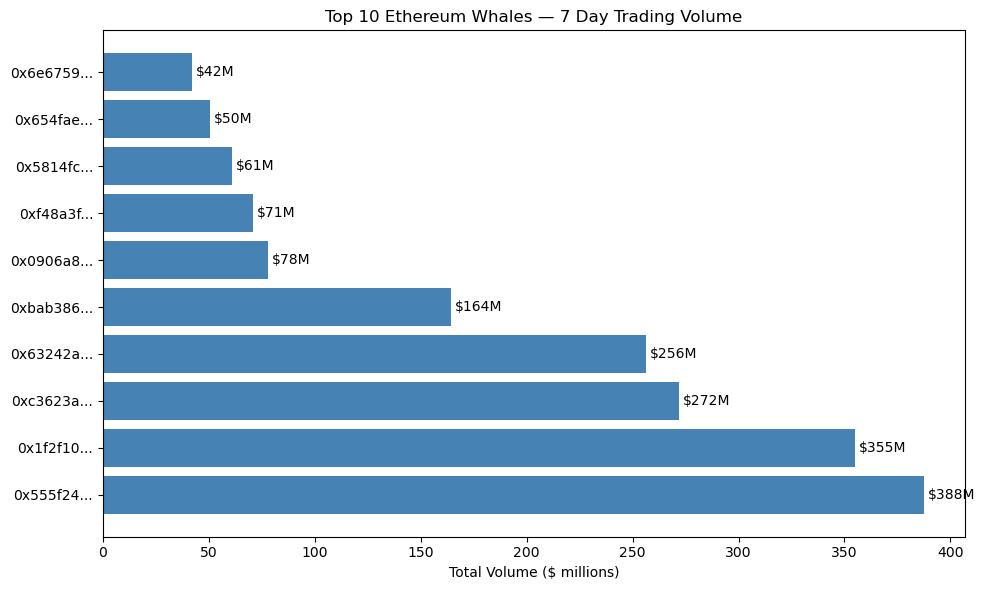

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

labels = [w[:8] + '...' for w in whales.index]
bars = ax.barh(labels, whales['total_volume'] / 1e6, color='steelblue')

ax.set_xlabel('Total Volume ($ millions)')
ax.set_title('Top 10 Ethereum Whales — 7 Day Trading Volume')
ax.bar_label(bars, fmt='$%.0fM', padding=3)

plt.tight_layout()
plt.savefig('whale_chart.png')
plt.show()

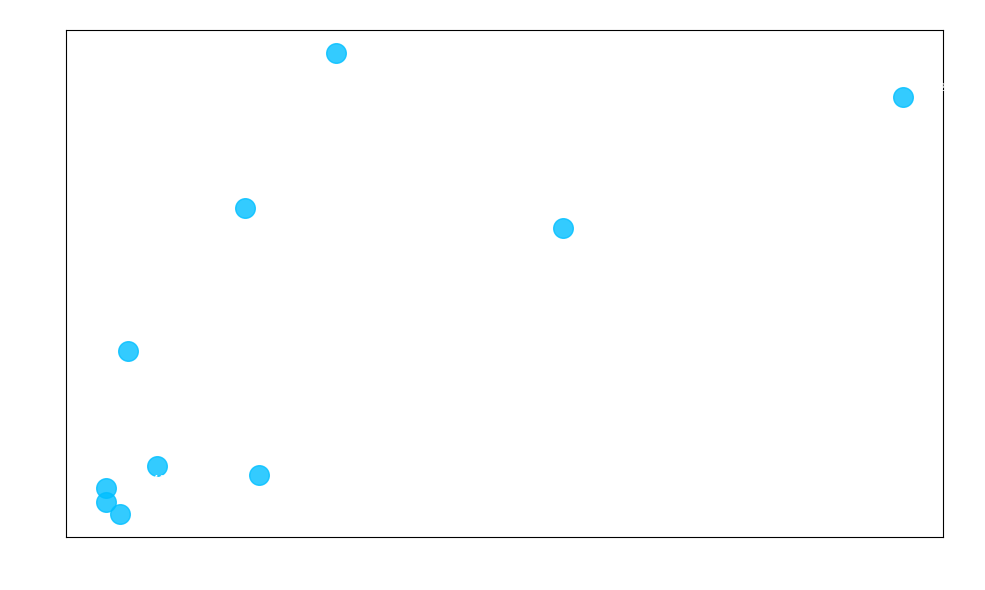

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(whales['trade_count'], whales['total_volume'] / 1e6, 
           color='#00BFFF', s=200, alpha=0.8)

for i, wallet in enumerate(whales.index):
    ax.annotate(wallet[:8] + '...', 
                (whales['trade_count'].iloc[i], whales['total_volume'].iloc[i] / 1e6),
                textcoords="offset points", xytext=(8, 4), fontsize=8, color='white')

ax.set_xlabel('Number of Trades', color='white')
ax.set_ylabel('Total Volume ($ millions)', color='white')
ax.set_title('Whale Types — Volume vs Trade Frequency', color='white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('whale_scatter.png', facecolor='#1a1a2e')
plt.show()

In [7]:
# Classify whales by behavior
df_whales = df[df['wallet'].isin(whales.index)].copy()

whale_types = []
for wallet in whales.index:
    trades = whales.loc[wallet, 'trade_count']
    avg = whales.loc[wallet, 'avg_trade']
    
    if trades > 100:
        whale_type = 'Bot / HFT'
    elif avg > 5000000:
        whale_type = 'Mega Whale'
    else:
        whale_type = 'Active Whale'
    
    whale_types.append({'wallet': wallet[:8] + '...', 'type': whale_type, 
                        'total_volume_M': round(whales.loc[wallet, 'total_volume'] / 1e6, 1),
                        'trade_count': trades,
                        'avg_trade_M': round(avg / 1e6, 2)})

whale_df = pd.DataFrame(whale_types)
print(whale_df.to_string(index=False))

     wallet         type  total_volume_M  trade_count  avg_trade_M
0x555f24... Active Whale           387.6           81         4.79
0x1f2f10...    Bot / HFT           354.8          236         1.50
0xc3623a... Active Whale           271.7           56         4.85
0x63242a...    Bot / HFT           256.1          143         1.79
0xbab386...   Mega Whale           164.1           24         6.84
0x0906a8... Active Whale            77.7           32         2.43
0xf48a3f... Active Whale            70.9           60         1.18
0x5814fc... Active Whale            60.8           18         3.38
0x654fae... Active Whale            50.3           18         2.80
0x6e6759... Active Whale            41.8           22         1.90


In [8]:
# Top tokens traded by whales
top_tokens = df.groupby('token')['amount_usd'].agg(
    total_volume='sum',
    trade_count='count'
).sort_values('total_volume', ascending=False).head(10)

top_tokens['total_volume_M'] = (top_tokens['total_volume'] / 1e6).round(1)
print(top_tokens[['total_volume_M', 'trade_count']])

       total_volume_M  trade_count
token                             
USDC            916.8          370
USDT            826.7          330
WETH            133.0           71
PYUSD           122.8           50
USDS             73.6           29
sUSDS            31.6           21
WBTC             29.7           15
RLUSD            28.0           12
7AΩ∞             27.5           12
weETH            24.9           16


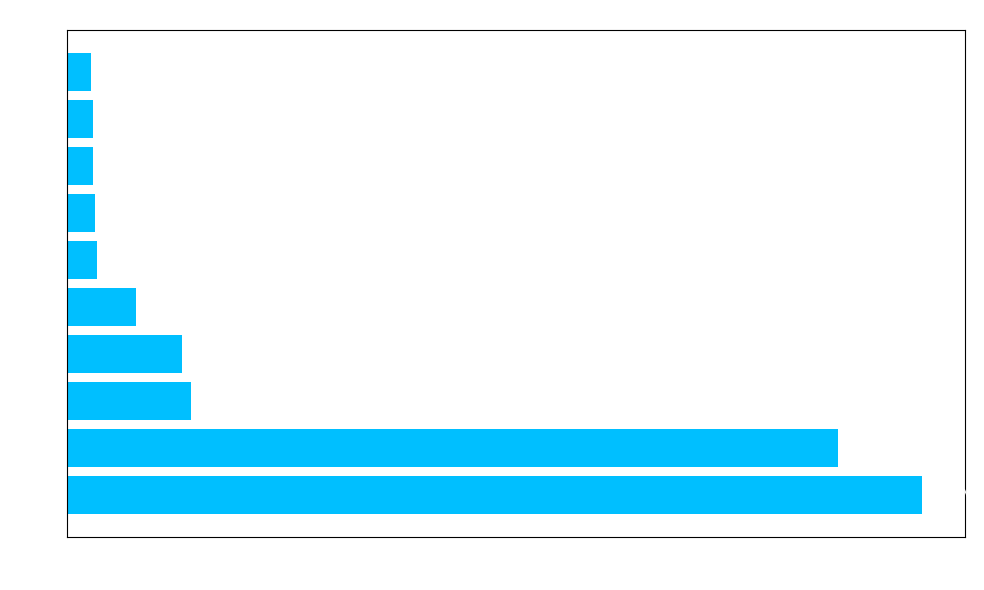

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top_tokens.index, top_tokens['total_volume_M'], color='#00BFFF')
ax.set_xlabel('Total Volume ($ millions)', color='white')
ax.set_title('Top Tokens Traded by Whales — 7 Days', color='white')
ax.bar_label(bars, fmt='$%.0fM', padding=3, color='white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('whale_tokens.png', facecolor='#1a1a2e')
plt.show()

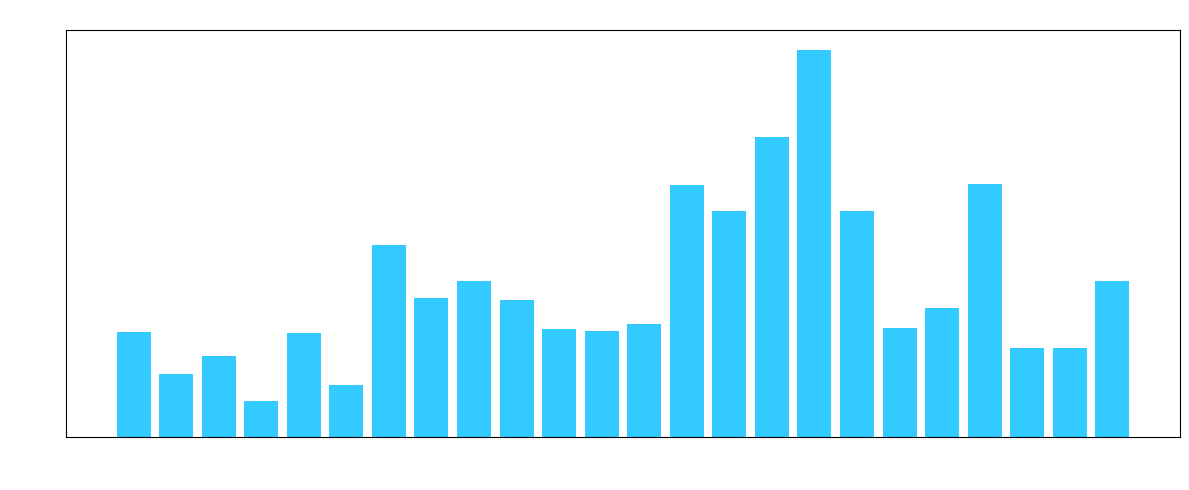

In [10]:
# Trading activity by hour
df['hour'] = pd.to_datetime(df['block_time']).dt.hour

hourly = df.groupby('hour')['amount_usd'].agg(
    total_volume='sum',
    trade_count='count'
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly['hour'], hourly['total_volume'] / 1e6, color='#00BFFF', alpha=0.8)
ax.set_xlabel('Hour (UTC)', color='white')
ax.set_ylabel('Total Volume ($ millions)', color='white')
ax.set_title('Whale Trading Activity by Hour of Day', color='white')
ax.set_xticks(range(0, 24))
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('whale_hourly.png', facecolor='#1a1a2e')
plt.show()


## Summary & Business Findings

### What I analyzed
Extracted 1,000 largest DEX trades on Ethereum over 7 days (min $100,000 per trade)
using Dune Analytics API. Identified top whale wallets and analyzed their behavior.

### Key Findings

**1. Whale Classification**
- 2 wallets identified as Bots/HFT — 143-236 trades/week, avg $1.5-1.8M per trade
- 1 Mega Whale — only 24 trades but avg $6.84M per trade
- 7 Active Whales — moderate frequency, $2-5M avg trade size

**2. Token Preference**
- 87% of whale volume is stablecoins (USDC $917M + USDT $827M)
- Whales are moving liquidity, not speculating on price

**3. Time Patterns**
- Peak activity at 16:00 UTC (NYSE open)
- Low activity 3-5 UTC (night in US + Europe)
- Whales follow traditional market hours — likely institutional players

### Conclusion
Ethereum whale activity is dominated by institutional players and bots.
Their stablecoin preference suggests liquidity management, not speculation.
Monitoring these wallets can provide early signals of large market movements.

### Tools
Python, Pandas, Matplotlib, Dune Analytics API

## 

In [11]:
df.to_csv('whales_data.csv', index=False)
print('saved!')

saved!
